# Study 776 — Valentine-Sparkle 💎

*For the curious.* Everyone *knows* jewellers rally into Valentine's Day — Signet (Kay, Zales, Jared) owns the biggest gifting quarter on the retail calendar, so the stock should be bid up into February 14 and fade after. We put 18 Valentine's Days (2009→2026) on the stand and asked the tape two plain questions: **does SIG rally into the holiday?** and **does it fade after?** The answer is a double bust.

## The claim, and why it's a clean test

Valentine's Day is the year's first big diamond/engagement-gift peak, and its date is **fixed years ahead** (February 14, every year). So *buy K sessions before, sell on/after the date* is calendar-known and zero-look-ahead. We measure SIG's **abnormal** return (SIG − SPY, total-return) so we're not just measuring beta — Signet is a volatile mid-cap with a market beta well above 1.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from valentine_sparkle import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SIG + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Valentine's Days resolved")


panel loaded; 18 of 18 Valentine's Days resolved


## The Valentine's calendar we test (fixed February 14 each year)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['year', 'valentines_date'])

,year,valentines_date
0,2009,2009-02-14
1,2010,2010-02-14
2,2011,2011-02-14
3,2012,2012-02-14
4,2013,2013-02-14
5,2014,2014-02-14
6,2015,2015-02-14
7,2016,2016-02-14
8,2017,2017-02-14
9,2018,2018-02-14


## The picture: mean cumulative abnormal return around Valentine's Day

Offset 0 is the Valentine's anchor. Left of zero is the *run-up* (the supposed rally in); right of zero is the *fade* window.

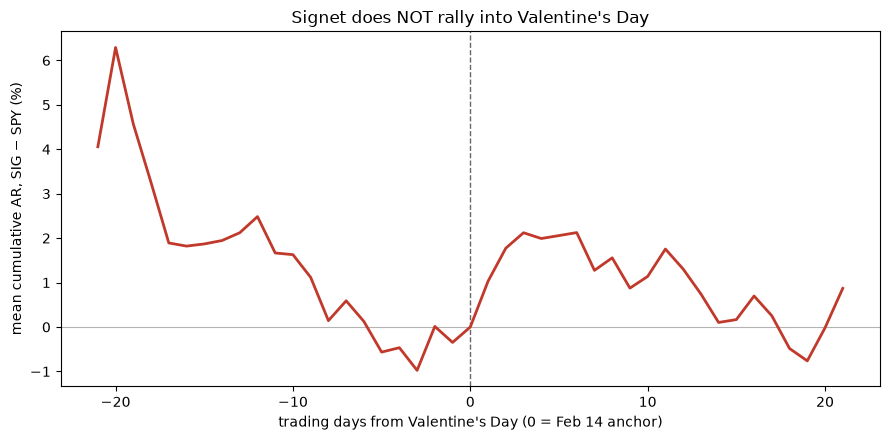

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#c0392b', lw=2)
ax.set_xlabel('trading days from Valentine\'s Day (0 = Feb 14 anchor)')
ax.set_ylabel('mean cumulative AR, SIG − SPY (%)')
ax.set_title('Signet does NOT rally into Valentine\'s Day')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | **-1.27%** | **-0.93** | 7/18 |
| 1-month run-up | -2.71% | -1.02 | 8/18 |
| 2-week fade | +1.14% | +0.52 | 9/18 |
| 1-month fade | +0.87% | +0.22 | 8/18 |

The bullish folklore is **absent — and mildly inverted**: in the two weeks *into* Valentine's, SIG has *under*-performed SPY by 1.27% on average (*t* = -0.93), and over a month by 2.71%. Neither is close to significant — but both point the *wrong* way for a rally. And the 'sell the holiday' fade? SIG is, if anything, *up* afterwards (both |*t*| < 0.6).

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up   n=18  mean=-1.275%  t=-0.929  hit 7/18
1mo run-up   n=18  mean=-2.714%  t=-1.021  hit 8/18
2wk fade     n=18  mean=+1.137%  t=+0.516  hit 9/18
1mo fade     n=18  mean=+0.869%  t=+0.224  hit 8/18


## So what?

The famous *buy the jeweller into Valentine's Day* trade is folklore twice over: the stock doesn't rally in (it drifts mildly *below* SPY) and it doesn't fade after. Every cut sits inside the noise. Verdict: **None signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.